## Load Modeling Dataset

Load the processed borough-level dataset created during the previous data preparation stage.

In [187]:
from pathlib import Path
import pandas as pd

PROCESSED_DATA = Path("../data/processed")

features_df = pd.read_csv(
    PROCESSED_DATA / "borough_year_features.csv"
)

print(features_df.shape)

features_df.head()

(264, 12)


,District,Year,Transactions,Average_Price,Median_Price,Min_Price,Max_Price,Price_STD,Average_Price_Growth,Median_Price_Growth,Target_Average_Price_Growth,Target_Median_Price_Growth
0,BARKING AND DAGENHAM,2018,2404,371419.146007,306750.0,100,20495000,9.097848e+05,NaN,NaN,0.059790,0.010595
1,BARKING AND DAGENHAM,2019,2146,393626.402144,310000.0,100,23160000,1.059141e+06,0.059790,0.010595,0.189852,0.032258
2,BARKING AND DAGENHAM,2020,1717,468356.971462,320000.0,100,41750000,1.792652e+06,0.189852,0.032258,-0.099888,0.046875
3,BARKING AND DAGENHAM,2021,2537,421573.503745,335000.0,100,50920000,1.783341e+06,-0.099888,0.046875,0.192617,0.104478
4,BARKING AND DAGENHAM,2022,2110,502775.688152,370000.0,100,98800000,2.466056e+06,0.192617,0.104478,-0.129364,0.010811


In [208]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   District                     264 non-null    object 
 1   Year                         264 non-null    int64  
 2   Transactions                 264 non-null    int64  
 3   Average_Price                264 non-null    float64
 4   Median_Price                 264 non-null    float64
 5   Min_Price                    264 non-null    int64  
 6   Max_Price                    264 non-null    int64  
 7   Price_STD                    264 non-null    float64
 8   Average_Price_Growth         231 non-null    float64
 9   Median_Price_Growth          231 non-null    float64
 10  Target_Average_Price_Growth  231 non-null    float64
 11  Target_Median_Price_Growth   231 non-null    float64
dtypes: float64(7), int64(4), object(1)
memory usage: 24.9+ KB


In [228]:
# Target variable

target = "Target_Average_Price_Growth"

# Input features

feature_columns = [
    "Transactions",
    "Average_Price",
    "Median_Price",
    "Min_Price",
    "Max_Price",
    "Price_STD",
    "Average_Price_Growth",
    "Median_Price_Growth",
]

# Feature matrix and target vector

X = features_df[feature_columns]
y = features_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (264, 8)
y shape: (264,)


## Chronological Train–Test Split

A chronological split is used to preserve the temporal order of the data.

The models are trained using observations from **2018–2023** and evaluated on **2024** data to better reflect a real-world forecasting scenario.

In [247]:
# Chronological train-test split

train_df = features_df[
    features_df["Year"] <= 2023
].copy()

test_df = features_df[
    features_df["Year"] == 2024
].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (198, 12)
Test shape : (33, 12)


In [265]:
# Verify the temporal split

train_df["Year"].value_counts().sort_index()

Year
2018    33
2019    33
2020    33
2021    33
2022    33
2023    33
Name: count, dtype: int64

In [312]:
test_df["Year"].value_counts().sort_index()

Year
2024    33
Name: count, dtype: int64

## Prepare Training and Test Sets

The feature matrices (`X`) and target vectors (`y`) are created for model training and evaluation.

A final validation step is performed to ensure that no missing values remain in the training features.

In [358]:
# Training data

X_train = train_df[feature_columns]
y_train = train_df[target]

# Test data

X_test = test_df[feature_columns]
y_test = test_df[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (198, 8)
y_train: (198,)
X_test : (33, 8)
y_test : (33,)


In [403]:
# Check missing values in training features

X_train.isna().sum()

Transactions            0
Average_Price           0
Median_Price            0
Min_Price               0
Max_Price               0
Price_STD               0
Average_Price_Growth    0
Median_Price_Growth     0
dtype: int64

In [447]:
train_df.isna().sum()

District                       0
Year                           0
Transactions                   0
Average_Price                  0
Median_Price                   0
Min_Price                      0
Max_Price                      0
Price_STD                      0
Average_Price_Growth           0
Median_Price_Growth            0
Target_Average_Price_Growth    0
Target_Median_Price_Growth     0
dtype: int64

## Correlation Between Growth Features

The relationship between the two historical growth variables is examined before model development.

In [ ]:
features_df[
    [
        "Average_Price_Growth",
        "Median_Price_Growth"
    ]
].corr()

Average_Price_Growth    0
Median_Price_Growth     0
dtype: int64

## Final Feature Set

The initial feature set is retained for the first round of modelling.

Feature refinement will be explored in later iterations if the initial models fail to achieve satisfactory predictive performance.

## Baseline Model

A baseline model is established before evaluating machine learning models.

This provides a reference point for comparing subsequent model performance.

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [ ]:
# Build baseline model

baseline_model = DummyRegressor(
    strategy="mean"
)

baseline_model.fit(
    X_train,
    y_train
)

,strategy,'mean'
,constant,None
,quantile,None


In [ ]:
# Generate baseline predictions

baseline_predictions = baseline_model.predict(
    X_test
)

In [ ]:
# Evaluate baseline model

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print(f"Baseline MAE : {baseline_mae:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline R²  : {baseline_r2:.4f}")

Baseline MAE : 0.0773
Baseline RMSE: 0.1120
Baseline R²  : -0.2289


In [ ]:
# Store baseline results

results = pd.DataFrame({
    "Model": ["Baseline"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse],
    "R2": [baseline_r2]
})

results.round(4)

## Linear Regression

Linear Regression is used as the first predictive model.

Its performance is compared with the baseline to determine whether a simple linear relationship is sufficient for predicting next-year average house price growth.

In [458]:
from sklearn.linear_model import LinearRegression

In [ ]:
# Train Linear Regression model

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# Generate predictions

linear_predictions = linear_model.predict(
    X_test
)

In [ ]:
# Evaluate Linear Regression

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print(f"Linear Regression MAE : {linear_mae:.4f}")
print(f"Linear Regression RMSE: {linear_rmse:.4f}")
print(f"Linear Regression R²  : {linear_r2:.4f}")

Linear Regression MAE : 0.0987
Linear Regression RMSE: 0.1499
Linear Regression R²  : -1.2013


In [ ]:
# Store results

results.loc[len(results)] = [
    "Linear Regression",
    linear_mae,
    linear_rmse,
    linear_r2
]

results.round(4)

,Model,MAE,RMSE,R2
0,Baseline,0.077272,0.111969,-0.228863
1,Linear Regression,0.098677,0.149859,-1.201277


## Model Coefficients

The estimated coefficients are inspected to understand the direction and relative influence of each feature within the linear model.

In [ ]:
pd.Series(
    linear_model.coef_,
    index=feature_columns
).sort_values()

## Feature Correlation

The correlation matrix is inspected to identify potential multicollinearity between the selected predictors.

In [ ]:
X_train.corr()

In [ ]:
X_train[
    [
        "Average_Price_Growth",
        "Median_Price_Growth"
    ]
].corr()

,Average_Price_Growth,Median_Price_Growth
Average_Price_Growth,1.000000,0.231326
Median_Price_Growth,0.231326,1.000000


## Linear Regression Results

Linear Regression did not outperform the baseline model on the test dataset.

This suggests that the current feature set does not provide a sufficiently strong linear signal for predicting next-year average house price growth.

The next step is to evaluate a Random Forest model, which is capable of capturing non-linear relationships and feature interactions.

## Random Forest

Random Forest is evaluated to determine whether a non-linear ensemble model can improve predictive performance compared with the baseline and Linear Regression.

In [467]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Train Random Forest model

rf_model = RandomForestRegressor(
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Generate predictions

rf_predictions = rf_model.predict(
    X_test
)

In [ ]:
# Evaluate Random Forest

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print(f"Random Forest MAE : {rf_mae:.4f}")
print(f"Random Forest RMSE: {rf_rmse:.4f}")
print(f"Random Forest R²  : {rf_r2:.4f}")

Random Forest MAE : 0.1040
Random Forest RMSE: 0.1513
Random Forest R²  : -1.2426


In [ ]:
# Store results

results.loc[len(results)] = [
    "Random Forest",
    rf_mae,
    rf_rmse,
    rf_r2
]

results.round(4)

## Target Distribution

The distribution of the target variable is inspected to determine whether its statistical characteristics may help explain the observed model performance.

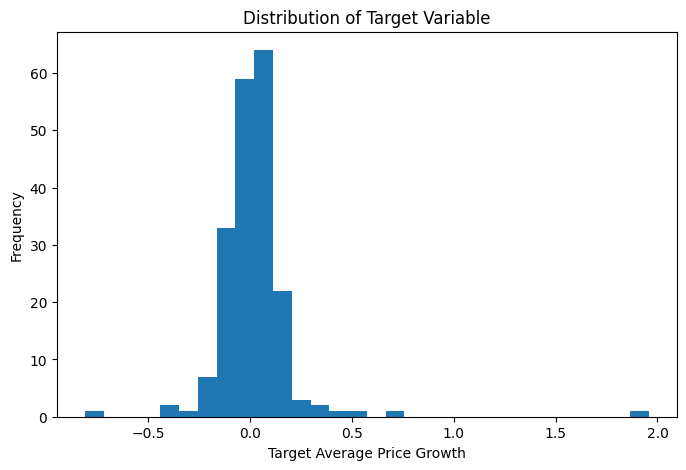

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    y_train,
    bins=30
)

plt.xlabel("Target Average Price Growth")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable")

plt.show()

### Extreme Target Values

The observations with the highest and lowest annual price growth are inspected to identify potential outliers.

In [ ]:
train_df[
    [
        "District",
        "Year",
        "Transactions",
        "Target_Average_Price_Growth"
    ]
].sort_values(
    by="Target_Average_Price_Growth",
    ascending=False
).head(10)

,District,Year,Transactions,Target_Average_Price_Growth
49,CITY OF LONDON,2019,299,-0.810006
53,CITY OF LONDON,2023,258,-0.374699
242,TOWER HAMLETS,2020,4355,-0.362420
105,HAMMERSMITH AND FULHAM,2019,2442,-0.319518
243,TOWER HAMLETS,2021,5943,-0.233297
202,NEWHAM,2020,2802,-0.227610
41,CAMDEN,2019,2239,-0.207364
28,BRENT,2022,3304,-0.203191
204,NEWHAM,2022,3277,-0.190044
155,ISLINGTON,2021,2934,-0.180071


In [ ]:
train_df[
    [
        "District",
        "Year",
        "Transactions",
        "Target_Average_Price_Growth"
    ]
].sort_values(
    by="Target_Average_Price_Growth",
    ascending=True
).head(10)

## Sensitivity Analysis

The previous analysis identified the City of London as a potential outlier, exhibiting unusually large positive and negative annual price growth.

Rather than removing these observations permanently, a sensitivity analysis is performed to evaluate their impact on model performance.

In [ ]:
# Remove City of London

train_no_city = train_df[
    train_df["District"] != "CITY OF LONDON"
].copy()

test_no_city = test_df[
    test_df["District"] != "CITY OF LONDON"
].copy()

In [ ]:
# Create training and testing sets

X_train_city = train_no_city[feature_columns]
y_train_city = train_no_city[target]

X_test_city = test_no_city[feature_columns]
y_test_city = test_no_city[target]

In [ ]:
# Train Random Forest

rf_model_city = RandomForestRegressor(
    random_state=42
)

rf_model_city.fit(
    X_train_city,
    y_train_city
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Generate predictions

rf_predictions_city = rf_model_city.predict(
    X_test_city
)

In [ ]:
# Evaluate model

rf_mae_city = mean_absolute_error(
    y_test_city,
    rf_predictions_city
)

rf_rmse_city = np.sqrt(
    mean_squared_error(
        y_test_city,
        rf_predictions_city
    )
)

rf_r2_city = r2_score(
    y_test_city,
    rf_predictions_city
)

print(f"Random Forest (without City of London) MAE : {rf_mae_city:.4f}")
print(f"Random Forest (without City of London) RMSE: {rf_rmse_city:.4f}")
print(f"Random Forest (without City of London) R²  : {rf_r2_city:.4f}")

Random Forest (without City of London) MAE : 0.0792
Random Forest (without City of London) RMSE: 0.1020
Random Forest (without City of London) R²  : -0.1986


In [ ]:
# Store results

results.loc[len(results)] = [
    "Random Forest (without City of London)",
    rf_mae_city,
    rf_rmse_city,
    rf_r2_city
]

results.round(4)

## XGBoost

XGBoost is evaluated as a gradient boosting algorithm capable of modelling more complex non-linear relationships than the previous models.

The objective is to determine whether increasing model complexity improves predictive performance using the current feature set.

In [480]:
from xgboost import XGBRegressor

In [ ]:
# Train XGBoost model

xgb_model = XGBRegressor(
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
# Generate predictions

xgb_predictions = xgb_model.predict(
    X_test
)

In [ ]:
# Evaluate XGBoost

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print(f"XGBoost MAE : {xgb_mae:.4f}")
print(f"XGBoost RMSE: {xgb_rmse:.4f}")
print(f"XGBoost R²  : {xgb_r2:.4f}")

XGBoost MAE : 0.1100
XGBoost RMSE: 0.1772
XGBoost R²  : -2.0778


In [ ]:
# Store results

results.loc[len(results)] = [
    "XGBoost",
    xgb_mae,
    xgb_rmse,
    xgb_r2
]

results.round(4)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Version 2 Summary

## Objective

Evaluate whether machine learning models can predict next-year average house price growth using borough-level transaction statistics.

## Models Evaluated

- Baseline
- Linear Regression
- Random Forest
- Random Forest (without City of London)
- XGBoost

## Key Findings

None of the evaluated machine learning models consistently outperformed the baseline model.

The results suggest that the current feature set contains insufficient predictive information for accurately forecasting next-year average house price growth.

Increasing model complexity alone did not improve predictive performance.

## Conclusion

The main limitation appears to be the available features rather than the choice of machine learning algorithm.

The next project phase will focus on feature engineering and the integration of additional external datasets to improve predictive performance.